# Imports

In [1]:
from nb_utils import set_root
PROJECT_DIR = set_root(1)

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import cv2
from scipy.signal import convolve2d

# Methods

In [4]:
def apply_fourier_transform(image):
    f_transform = np.fft.fft2(image)
    f_shift = np.fft.fftshift(f_transform)
    magnitude_spectrum = np.log(np.abs(f_shift) + 1) # 20 * np.log(np.abs(f_shift) + 1)
    return magnitude_spectrum, f_shift


In [5]:
def box_blur_manual(img, ksize=(3, 3)):
    # Tamanho do kernel
    k_h, k_w = ksize
    pad_h = k_h // 2
    pad_w = k_w // 2

    # Cria uma cópia da imagem com padding (borda replicada)
    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='reflect')

    # Cria a imagem de saída
    output = np.zeros_like(img, dtype=np.uint8)

    # Aplica o filtro manualmente
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i:i + k_h, j:j + k_w]
            mean_val = np.mean(region)
            output[i, j] = int(mean_val)

    return output

# Parameters

In [6]:
path_assets = PROJECT_DIR / 'assets'
path_imgs_atv = path_assets / "atv02_lista02-assets"

# Questão 09

In [7]:
img_names = ["cameraman.png", "cameraman_pattern.png"]
# img = cv2.imread(path_assets / "atv02_lista02-assets" / 'cameraman_pattern.png', cv2.IMREAD_GRAYSCALE)
imgs = {
    i.split(".")[0]: cv2.imread(path_imgs_atv / i, cv2.IMREAD_GRAYSCALE) for i in img_names
}

# imgs["cameraman_pattern_cut"] = imgs["cameraman_pattern"][0:150, 0:200]

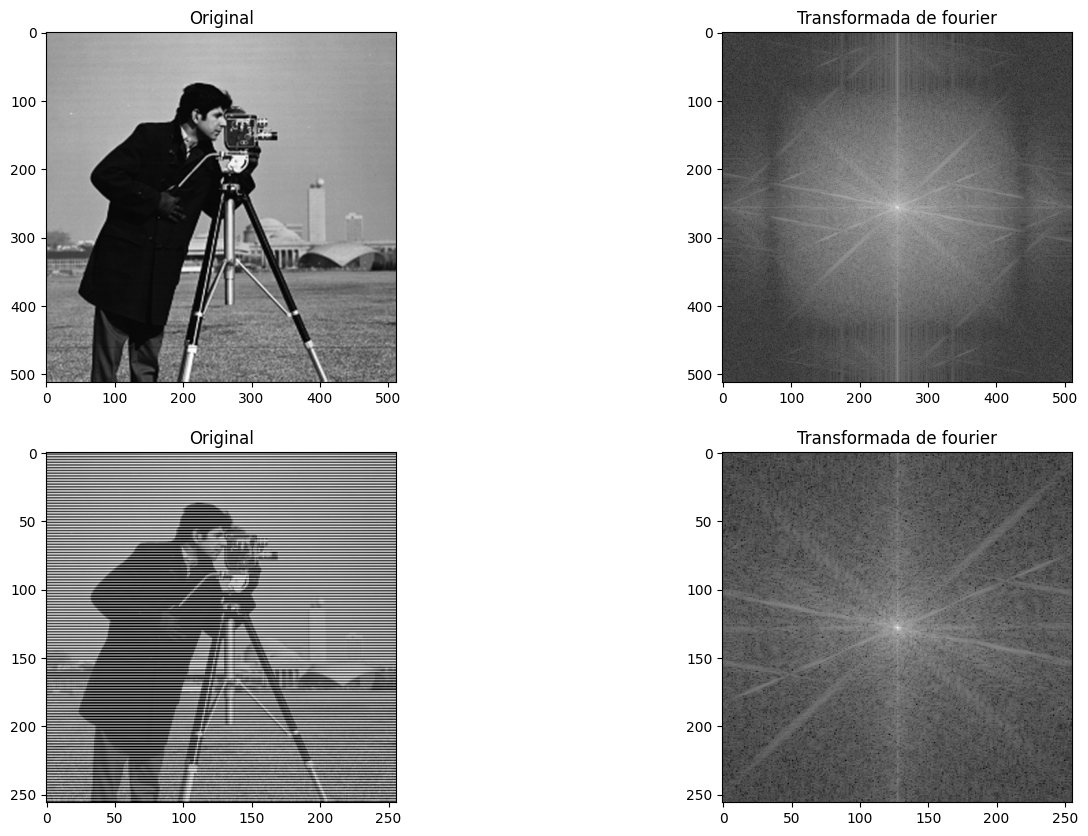

In [8]:
fourier = {
    name: {
        "tft": apply_fourier_transform(img)[1],
        "spectrum": apply_fourier_transform(img)[0]
    } for name, img in imgs.items()
}
# Mostrar imagem resultante
fig, ax = plt.subplots(len(fourier), 2, figsize=(16, 10))
for _ax, name in zip(ax, fourier.keys()):
    _ax[0].imshow(imgs[name], cmap='gray')
    _ax[0].set_title('Original')
    _ax[1].imshow(fourier[name]["spectrum"].astype(float), cmap='gray')
    _ax[1].set_title('Transformada de fourier')
    #_ax[0].axis('off')
    #_ax[1].axis('off')
fig.savefig(path_assets / "atv02-q09-init.png", bbox_inches='tight', dpi=400)
plt.show()


## a) uma solução aplicada no domínio da frequência

In [9]:
img = imgs["cameraman_pattern"]
rows, cols = img.shape
crow, ccol = rows // 2 , cols // 2  # centro da imagem

# Aplicar a Transformada de Fourier
dft = np.fft.fft2(img)
dft_shift = np.fft.fftshift(dft)

# Criar o filtro Gaussiano
sigmas = [10, 20, 40, 50, 100]

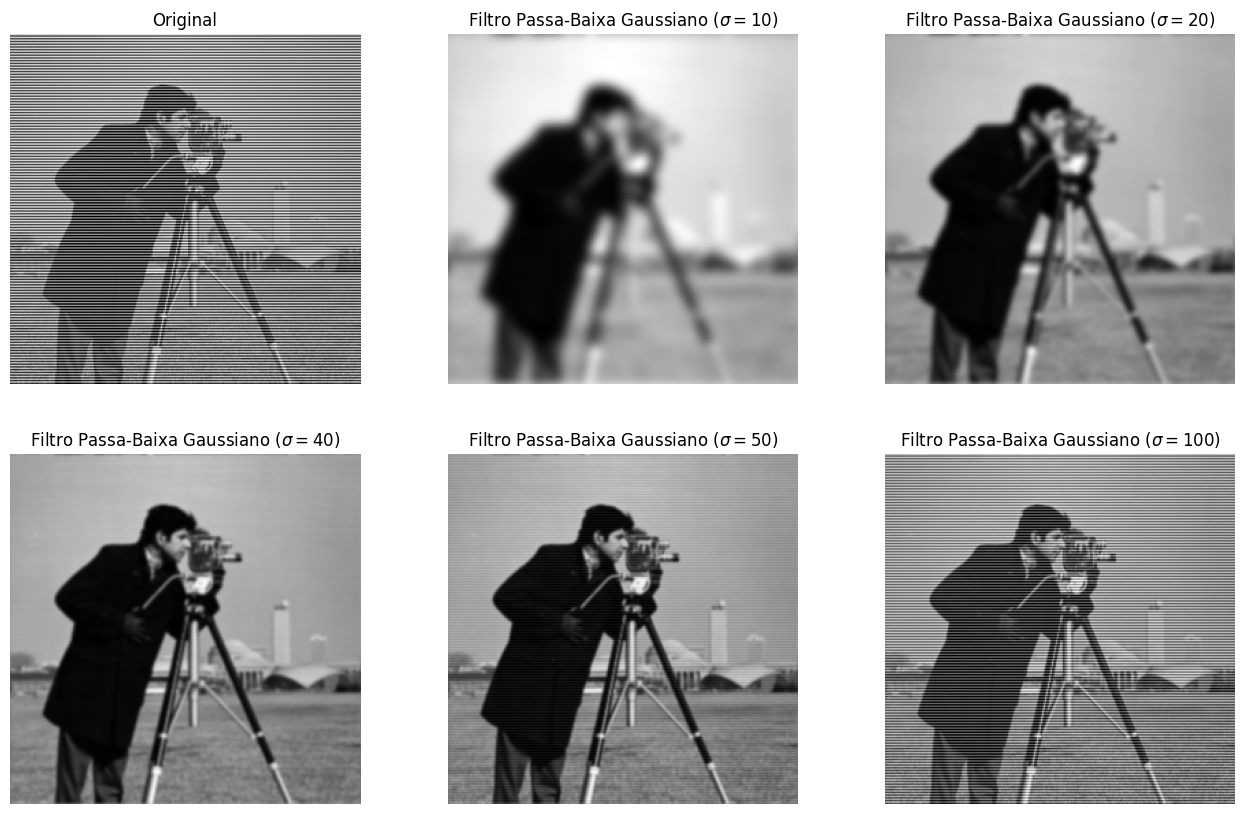

In [10]:
fig, ax = plt.subplots(2, (len(sigmas) // 2) + 1, figsize=(16, 10))
ax = ax.flatten()
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original')
ax[0].axis('off')
for idx, sigma in enumerate(sigmas):
    # Calcula filtro passa-baixa gaussiano
    u = np.arange(-ccol, ccol)
    v = np.arange(-crow, crow)
    U, V = np.meshgrid(u, v)
    D = np.sqrt(U**2 + V**2)
    H = np.exp(-(D**2) / (2 * sigma**2))

    # Aplicar o filtro
    filtered_dft = dft_shift * H

    # Transformada Inversa
    f_ishift = np.fft.ifftshift(filtered_dft)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.abs(img_back)

    ax[idx + 1].imshow(img_back, cmap='gray')
    ax[idx + 1].set_title('Filtro Passa-Baixa Gaussiano ' + rf"($\sigma={sigma}$)")
    ax[idx + 1].axis('off')
fig.savefig(path_assets / "atv02-q09-a.png", bbox_inches='tight', dpi=400)
plt.show()

## b) uma solução aplicada no domínio espacial

Vamos aplicar um filtro box considerando uma vizinhança 2x2, 3x3 e 4x4 para avaliar a melhor vizinhança.

In [ ]:
# mascaras utilizadas
hs = {
    "Mascara 01":(1 / 9) * np.array(
        [
            [0, 0, 0],
            [0, 1, 1],
            [0, 1, 1]
        ]
    ),
    "Mascara 02":(1 / 9) * np.array(
        [
            [0, 1, 0],
            [1, 0, 1],
            [0, 1, 0]
        ]
    ),
    "Mascara 03":(1 / 9) * np.array(
        [
            [1, 1, 1],
            [1, 0, 1],
            [1, 1, 1]
        ]
    ),
    "Mascara 04":(1 / 9) * np.array(
        [
            [1, 0, 1],
            [0, 0, 0],
            [1, 0, 1]
        ]
    ),
}

# aplicação da correlação cruzada
filtered_img = {
    key: convolve2d(
        imgs["cameraman_pattern"],
        h,
        mode='same',
        boundary='fill',
        fillvalue=0
    ).round().astype(int) for key, h in hs.items()
}

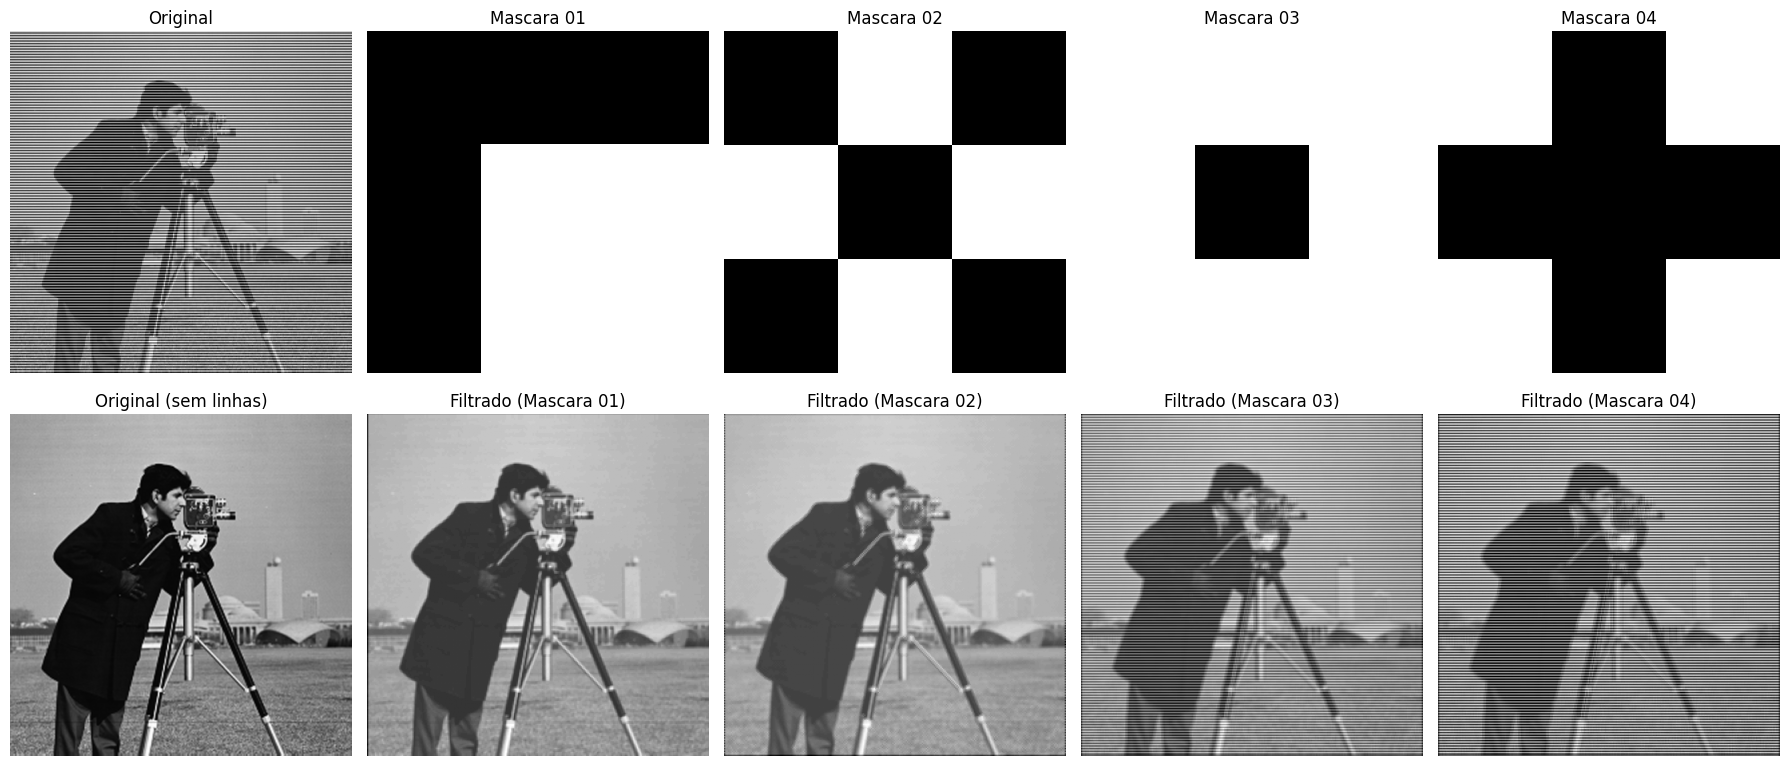

In [157]:
fig, ax = plt.subplots(2, len(filtered_img.keys()) + 1, figsize=(18, 8))

ax[0, 0].set_title('Original')
ax[0, 0].imshow(imgs["cameraman_pattern"], cmap='gray')
ax[0, 0].axis('off')

ax[1, 0].set_title('Original (sem linhas)')
ax[1, 0].imshow(imgs["cameraman"], cmap='gray')
ax[1, 0].axis('off')

# Exibir as máscaras e as imagens filtradas
for _ax, (title, content) in zip(ax.T[1:], filtered_img.items()):
    # Normalizar a máscara para o intervalo [0, 1]
    mask = hs[title]
    mask_normalized = (mask - mask.min()) / (mask.max() - mask.min())

    _ax[0].imshow(mask_normalized, cmap='gray')
    _ax[0].set_title(title)
    _ax[0].axis('off')

    _ax[1].imshow(content, cmap='gray')
    _ax[1].set_title(f"Filtrado ({title})")
    _ax[1].axis('off')

fig.tight_layout()
fig.savefig(path_assets / "atv02-q09-03.png", dpi=400, bbox_inches='tight')
plt.show()

### Conclusão
Entre as máscaras testadas, a Máscara 1 apresentou os melhores resultados, conseguindo remover completamente as linhas horizontais presentes na imagem cameraman_pattern.png. Além disso, essa máscara conseguiu manter os detalhes da imagem original e apresentou o menor nível de borramento.

A Máscara 2 também foi capaz de eliminar as linhas horizontais, mas apresentou um borramento mais evidente, o que comprometeu visualmente a qualidade da imagem. Por outro lado, as Máscaras 3 e 4 não foram eficazes. Ambas não foram eficientes em remover as linhas horizontais e ainda introduziram um efeito de borramento significativo, prejudicando a nitidez e os detalhes da imagem.

Dessa forma, temos que a **Máscara 1** foi a mais adequada para resolver o problema, equilibrando a remoção do padrão de linhas com a preservação da qualidade da imagem.

* **Máscara selecionada:**

$$
h = \left(\frac{1}{9}\right) \cdot \left[\begin{matrix}
    0 & 0 & 0 \\
    0 & 1 & 1 \\
    0 & 1 & 1 \\
\end{matrix}\right]
$$